In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub", "torch", "scikit-learn", "pandas", "numpy", "matplotlib", "--quiet"])

0

In [2]:
import os
import math
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [3]:
path     = kagglehub.dataset_download("robikscube/hourly-energy-consumption")
csv_path = os.path.join(path, "AEP_hourly.csv")

df = pd.read_csv(csv_path)
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

print(df.shape)
print(df.head())

Using Colab cache for faster access to the 'hourly-energy-consumption' dataset.
(121273, 2)
             Datetime   AEP_MW
0 2004-10-01 01:00:00  12379.0
1 2004-10-01 02:00:00  11935.0
2 2004-10-01 03:00:00  11692.0
3 2004-10-01 04:00:00  11597.0
4 2004-10-01 05:00:00  11681.0


In [4]:
df["hour_sin"]  = np.sin(2 * np.pi * df["Datetime"].dt.hour       / 24)
df["hour_cos"]  = np.cos(2 * np.pi * df["Datetime"].dt.hour       / 24)
df["dow_sin"]   = np.sin(2 * np.pi * df["Datetime"].dt.dayofweek  / 7)
df["dow_cos"]   = np.cos(2 * np.pi * df["Datetime"].dt.dayofweek  / 7)
df["month_sin"] = np.sin(2 * np.pi * df["Datetime"].dt.month      / 12)
df["month_cos"] = np.cos(2 * np.pi * df["Datetime"].dt.month      / 12)

feature_cols = ["AEP_MW", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]
INPUT_SIZE   = len(feature_cols)

feat_scaler  = MinMaxScaler()
mw_scaler    = MinMaxScaler()

feat_scaled  = feat_scaler.fit_transform(df[feature_cols].values).astype(np.float32)
mw_scaled    = mw_scaler.fit_transform(df[["AEP_MW"]].values).astype(np.float32)

SEQ_LEN = 168

def create_sequences(feat_data, mw_data, seq_len):
    X, y = [], []
    for i in range(len(feat_data) - seq_len):
        X.append(feat_data[i : i + seq_len])
        y.append(mw_data[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = create_sequences(feat_scaled, mw_scaled, SEQ_LEN)
print(f"X: {X.shape}  y: {y.shape}")

X: (121105, 168, 7)  y: (121105, 1)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

BATCH_SIZE = 64
train_size = int(len(X) * 0.8)

X_train_t = torch.FloatTensor(X[:train_size]).to(device)
y_train_t = torch.FloatTensor(y[:train_size]).to(device)
X_test_t  = torch.FloatTensor(X[train_size:]).to(device)
y_test_t  = torch.FloatTensor(y[train_size:]).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(f"Train: {X_train_t.shape}  Test: {X_test_t.shape}")

Using device: cuda
Train: torch.Size([96884, 168, 7])  Test: torch.Size([24221, 168, 7])


In [6]:
HIDDEN_SIZE = 64
NUM_LAYERS  = 2
EPOCHS      = 50
LR          = 0.001
PATIENCE    = 7
BATCH_SIZE  = 32

In [7]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(
            INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS,
            batch_first=True, dropout=0.2, bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Linear(HIDDEN_SIZE * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

In [8]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS,
            batch_first=True, dropout=0.2, bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Linear(HIDDEN_SIZE * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [9]:
class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(
            INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS,
            batch_first=True, dropout=0.2, bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Linear(HIDDEN_SIZE * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class TransformerModel(nn.Module):
    def __init__(self, d_model=128, nhead=8, num_encoder_layers=3, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(INPUT_SIZE, d_model)
        self.pos_enc     = PositionalEncoding(d_model)
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :])

In [11]:
def train_model(model, loader, epochs, model_name):
    model.to(device)
    optimizer  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion  = nn.HuberLoss()
    best_loss  = float("inf")
    patience_c = 0
    save_path  = f"best_{model_name}.pt"

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss   = epoch_loss / len(loader)
        scheduler.step(avg_loss)
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"[{model_name}] Epoch {epoch:>2}/{epochs}  Loss: {avg_loss:.6f}  LR: {current_lr:.6f}")

        if avg_loss < best_loss - 1e-6:
            best_loss  = avg_loss
            patience_c = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_c += 1
            if patience_c >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(torch.load(save_path, map_location=device))
    return model


def evaluate_model(model, X_t, y_t):
    model.eval()
    all_preds = []

    eval_loader = DataLoader(
        TensorDataset(X_t, y_t),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    with torch.no_grad():
        for xb, _ in eval_loader:
            preds = model(xb).cpu().numpy()
            all_preds.append(preds)

    all_preds  = np.concatenate(all_preds, axis=0)
    preds_inv  = mw_scaler.inverse_transform(all_preds)
    actual_inv = mw_scaler.inverse_transform(y_t.cpu().numpy())
    rmse = math.sqrt(mean_squared_error(actual_inv, preds_inv))
    mae  = mean_absolute_error(actual_inv, preds_inv)
    return preds_inv, actual_inv, rmse, mae

In [12]:
model_registry = {
    "RNN":         RNNModel(),
    "LSTM":        LSTMModel(),
    "GRU":         GRUModel(),
    "Transformer": TransformerModel(),
}

results     = {}
predictions = {}
actual_inv  = None

for name, model in model_registry.items():
    print(f"\n{'='*45}\n  Training {name}\n{'='*45}")
    trained                       = train_model(model, train_loader, EPOCHS, name)
    preds_inv, act_inv, rmse, mae = evaluate_model(trained, X_test_t, y_test_t)
    results[name]                 = {"RMSE": rmse, "MAE": mae}
    predictions[name]             = preds_inv
    actual_inv                    = act_inv
    print(f"  >> {name}  RMSE: {rmse:.4f}  |  MAE: {mae:.4f}")


  Training RNN
[RNN] Epoch  1/50  Loss: 0.001388  LR: 0.001000
[RNN] Epoch  2/50  Loss: 0.000464  LR: 0.001000
[RNN] Epoch  3/50  Loss: 0.000317  LR: 0.001000
[RNN] Epoch  4/50  Loss: 0.000269  LR: 0.001000
[RNN] Epoch  5/50  Loss: 0.000251  LR: 0.001000
[RNN] Epoch  6/50  Loss: 0.000240  LR: 0.001000
[RNN] Epoch  7/50  Loss: 0.000234  LR: 0.001000
[RNN] Epoch  8/50  Loss: 0.000237  LR: 0.001000
[RNN] Epoch  9/50  Loss: 0.000232  LR: 0.001000
[RNN] Epoch 10/50  Loss: 0.000230  LR: 0.001000
[RNN] Epoch 11/50  Loss: 0.000223  LR: 0.001000
[RNN] Epoch 12/50  Loss: 0.000223  LR: 0.001000
[RNN] Epoch 13/50  Loss: 0.000223  LR: 0.001000
[RNN] Epoch 14/50  Loss: 0.000221  LR: 0.001000
[RNN] Epoch 15/50  Loss: 0.000214  LR: 0.001000
[RNN] Epoch 16/50  Loss: 0.000213  LR: 0.001000
[RNN] Epoch 17/50  Loss: 0.000210  LR: 0.001000
[RNN] Epoch 18/50  Loss: 0.000210  LR: 0.001000
[RNN] Epoch 19/50  Loss: 0.000207  LR: 0.001000
[RNN] Epoch 20/50  Loss: 0.000203  LR: 0.001000
[RNN] Epoch 21/50  Loss:

In [12]:
print(f"\n{'='*38}")
print(f"{'Model':<14} {'RMSE':>10} {'MAE':>10}")
print("-" * 38)
for name, m in results.items():
    print(f"{name:<14} {m['RMSE']:>10.4f} {m['MAE']:>10.4f}")

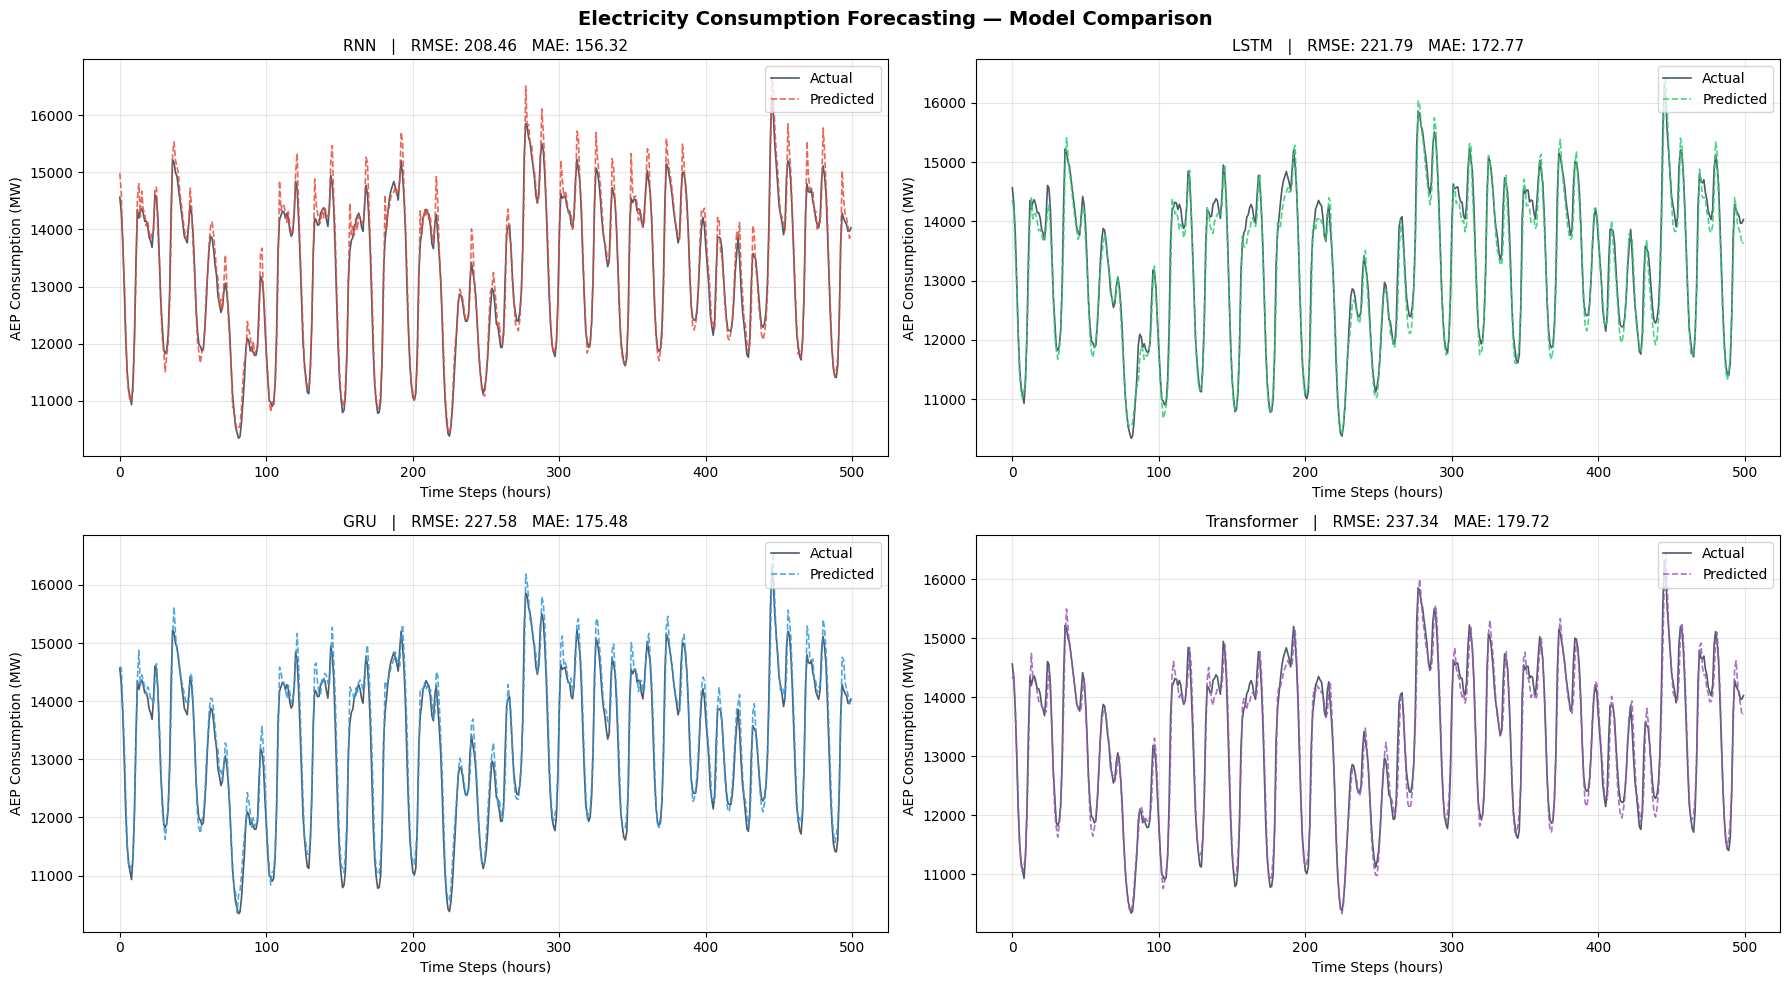

Plot saved.


In [13]:
PLOT_N = 500
colors = {"RNN": "#E74C3C", "LSTM": "#2ECC71", "GRU": "#3498DB", "Transformer": "#9B59B6"}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("Electricity Consumption Forecasting — Model Comparison", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, (name, preds) in enumerate(predictions.items()):
    ax = axes[i]
    ax.plot(actual_inv[:PLOT_N], label="Actual",    color="#2C3E50",    linewidth=1.2, alpha=0.85)
    ax.plot(preds[:PLOT_N],      label="Predicted", color=colors[name], linewidth=1.2, alpha=0.85, linestyle="--")
    ax.set_title(f"{name}   |   RMSE: {results[name]['RMSE']:.2f}   MAE: {results[name]['MAE']:.2f}", fontsize=11)
    ax.set_xlabel("Time Steps (hours)")
    ax.set_ylabel("AEP Consumption (MW)")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("electricity_forecast_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")